# Notebook 6 — Trust Regions: Importance Sampling, KL Divergence, TRPO & PPO

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. **Trust Regions: Importance Sampling, KL, TRPO, PPO** ← *you are here*
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

Still **only `numpy` and `matplotlib`**. By the end of this notebook you will have
written, from scratch, the exact algorithm used to RL-fine-tune the first
generation of chat models: **PPO with a KL penalty to a reference policy**.

### Recap

Notebook 5 gave us the policy gradient
$\nabla J = \mathbb E_{\pi_\theta}\big[\hat A_t\, \nabla\log\pi_\theta(a_t\mid s_t)\big]$, variance
reduction with baselines and GAE, and a working actor-critic. It ended on two
problems:

1. **Sample inefficiency.** Each batch of experience is used for exactly one
   gradient step, then thrown away. For LLMs, generating that batch is the
   most expensive part of training.
2. **Fragility.** One step that's too large can change the policy's behavior
   drastically. Since the policy generates its own data, that damage can be
   **permanent**. And a learning rate measures step size in *parameter* space,
   which says little about how much *behavior* changes.

### What this notebook covers

- **Importance sampling (IS)**: how to reuse data from an old policy — and why
  its variance explodes when the policies drift apart.
- The **surrogate objective**, and an *exact* experiment (on a GridWorld whose
  model we know) showing that it's trustworthy only **locally**.
- **KL divergence** from scratch: asymmetry, mode-covering vs. mode-seeking,
  and the **k1 / k2 / k3 estimators** used in RLHF and GRPO.
- **TRPO**: natural gradient + conjugate gradient + line search, built by
  hand, which steps a fixed distance in *distribution* space.
- **PPO-clip**: the objective derived and plotted, its gradient derived by
  hand, and a full PPO implementation on CartPole, with an ablation showing
  what clipping buys.
- **PPO with a KL penalty to a reference model** — the RLHF recipe — on our
  tiny token generator, checked against the **closed-form optimal policy**
  $\pi^{*}(y) \propto \pi_{\text{ref}}(y)\,e^{r(y)/\beta}$, including a live
  demonstration of **reward hacking**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

# ---------------- From notebooks 4-5, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)


class CartPole:
    '''CartPole-v1 dynamics in pure numpy (notebook 4).'''
    def __init__(self, max_steps=500, seed=None):
        self.gravity, self.m_cart, self.m_pole, self.half_len = 9.8, 1.0, 0.1, 0.5
        self.force_mag, self.dt = 10.0, 0.02
        self.x_limit, self.theta_limit = 2.4, 12 * 2 * np.pi / 360
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.state = self.rng.uniform(-0.05, 0.05, size=4); self.t = 0
        return self.state.copy()

    def step(self, action):
        x, x_dot, th, th_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(th), np.sin(th)
        total_m = self.m_cart + self.m_pole; pml = self.m_pole * self.half_len
        temp = (force + pml * th_dot ** 2 * sin_t) / total_m
        th_acc = (self.gravity * sin_t - cos_t * temp) / (self.half_len * (4.0 / 3.0 - self.m_pole * cos_t ** 2 / total_m))
        x_acc = temp - pml * th_acc * cos_t / total_m
        x, x_dot = x + self.dt * x_dot, x_dot + self.dt * x_acc
        th, th_dot = th + self.dt * th_dot, th_dot + self.dt * th_acc
        self.state = np.array([x, x_dot, th, th_dot]); self.t += 1
        terminated = bool(abs(x) > self.x_limit or abs(th) > self.theta_limit)
        return self.state.copy(), 1.0, terminated, self.t >= self.max_steps


def compute_gae(rewards, values, next_values, terminated, episode_end, gamma, lam):
    '''Notebook 5, Section 6 -- verified there at lambda = 0 and lambda = 1.'''
    T = len(rewards)
    adv = np.zeros(T)
    running = 0.0
    for t in reversed(range(T)):
        delta = rewards[t] + gamma * next_values[t] * (1.0 - terminated[t]) - values[t]
        running = delta + gamma * lam * (1.0 - episode_end[t]) * running
        adv[t] = running
    return adv, adv + values

## 1. The goal: many gradient steps per batch

In LLM RL, one training iteration looks like this:

1. **Generate** completions for a batch of prompts with the current model — autoregressively,
   token by token. Slow and expensive.
2. **Score** them (reward model, verifier). Moderately expensive.
3. **Update** the model with gradient steps. Comparatively cheap.

Steps 1–2 dominate the cost, so we'd like to squeeze **many** gradient steps
out of each batch. But after the first step, the policy $\pi_\theta$ is no longer the
policy $\pi_{\theta_{\text{old}}}$ that generated the data. The policy gradient
$\mathbb E_{a\sim\pi_\theta}[\cdot]$ is an expectation under the *current* policy, and our
samples now come from a *different* one. Notebook 3 called this being
**off-policy**. We need a way to correct for the mismatch.

## 2. Importance sampling: reweighting samples from the wrong distribution

We want $\mathbb E_{x\sim p}[f(x)]$ but can only sample from $q$. Multiply and divide by $q$:

$$
\mathbb E_{x\sim p}[f(x)] = \sum_x p(x) f(x) = \sum_x q(x)\,\frac{p(x)}{q(x)}\,f(x) = \mathbb E_{x\sim q}\Big[\underbrace{\tfrac{p(x)}{q(x)}}_{\text{importance weight}}\, f(x)\Big].
$$

Sample from $q$ and weight each sample by how much more (or less) likely it
is under $p$. It's exactly unbiased, as long as $q(x) > 0$ wherever $p(x) f(x) \ne 0$.

The catch is **variance**. If $q$ rarely samples a region where $p$ puts
mass, the few samples that land there get enormous weights, and the estimate
is dominated by a handful of lucky draws. Let's watch it happen. Target:
$p = \mathcal N(0,1)$, estimating $\mathbb E_p[x^2] = 1$, with samples from
$q = \mathcal N(\mu, 1)$ for increasingly distant $\mu$.

In [2]:
def normal_pdf(x, mu):
    return np.exp(-0.5 * (x - mu) ** 2) / np.sqrt(2 * np.pi)

rng = np.random.default_rng(0)
print(f"{'q = N(mu,1), mu':>16} | {'mean of estimates':>17} | {'std of estimate':>15} | {'largest single weight':>21}")
for mu in [0.0, 0.5, 1.0, 2.0, 3.0]:
    estimates, max_w = [], 0.0
    for _ in range(500):
        x = rng.normal(mu, 1.0, size=1000)
        w = normal_pdf(x, 0.0) / normal_pdf(x, mu)
        estimates.append(np.mean(w * x ** 2)); max_w = max(max_w, w.max())
    print(f"{mu:>16} | {np.mean(estimates):>17.3f} | {np.std(estimates):>15.3f} | {max_w:>21.1f}")

 q = N(mu,1), mu | mean of estimates | std of estimate | largest single weight
             0.0 |             1.002 |           0.043 |                   1.0
             0.5 |             1.001 |           0.068 |                   9.2
             1.0 |             0.994 |           0.166 |                  89.8
             2.0 |             1.158 |           3.231 |                6004.2
             3.0 |             1.082 |           5.144 |               25059.5


At $\mu = 0$ ($q = p$) all weights are 1 and the estimate is tight. As $q$
drifts away the estimate *stays unbiased on average*, but its spread grows
quickly and single weights reach into the hundreds. (For two unit Gaussians,
the variance of the weights is exactly $e^{\mu^2} - 1$: exponential in the
squared distance.) **IS works beautifully when the two distributions are
close, and falls apart when they aren't.** That sentence is the entire
motivation for trust regions.

### Why not reweight whole trajectories?

For a trajectory, the correct weight is a product over its steps (the
dynamics cancel, as in notebook 5):

$$
\frac{P_\theta(\tau)}{P_{\text{old}}(\tau)} = \prod_{t=0}^{T-1} \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\text{old}}(a_t\mid s_t)} .
$$

Each factor is close to 1, but a product of hundreds of factors "close to 1"
is anything but. Let's simulate a token policy over a 50-word vocabulary,
where the new policy differs from the old one by only a tiny per-token
perturbation, and look at the weight of whole sequences of length $T$.

In [3]:
rng = np.random.default_rng(1)
vocab = 50
logits_old = rng.normal(size=vocab)
logits_new = logits_old + 0.1 * rng.normal(size=vocab)     # a small per-token change
p_old, p_new = softmax(logits_old), softmax(logits_new)
per_token_kl = np.sum(p_old * np.log(p_old / p_new))
print(f"per-token KL(old || new) = {per_token_kl:.4f}  (tiny)")

print(f"{'sequence length T':>18} | {'median weight':>13} | {'99th pct weight':>15} | {'std of weights':>14}")
for T in [1, 10, 50, 200, 1000]:
    toks = rng.choice(vocab, size=(5000, T), p=p_old)
    w = np.exp(np.sum(np.log(p_new[toks]) - np.log(p_old[toks]), axis=1))
    print(f"{T:>18} | {np.median(w):>13.3f} | {np.percentile(w, 99):>15.3f} | {w.std():>14.3f}")

per-token KL(old || new) = 0.0036  (tiny)
 sequence length T | median weight | 99th pct weight | std of weights
                 1 |         1.006 |           1.139 |          0.084
                10 |         0.977 |           1.753 |          0.269
                50 |         0.826 |           3.387 |          0.649
               200 |         0.479 |           7.007 |          1.583


              1000 |         0.027 |          12.262 |         10.018


As sequences get longer, the **median** weight drifts toward 0 while the
**tail** gets huge: most sequences are nearly ignored and a few dominate. A
real LLM completion is hundreds or thousands of tokens long, so full-sequence
IS is hopeless.

The practical fix, used by PPO (and inherited by GRPO), is to use **one ratio
per step** — $\rho_t = \pi_\theta(a_t\mid s_t)/\pi_{\text{old}}(a_t\mid s_t)$ — and to ignore
the fact that the *state distribution* also changed. That's an approximation.
Section 3 shows exactly when it's a good one.

## 3. The surrogate objective, and why it's only locally trustworthy

Apply per-step IS to the policy-gradient objective, with advantages computed
under the old policy:

$$
L_{\theta_{\text{old}}}(\theta) = \mathbb E_{s,a\sim\pi_{\text{old}}}\Big[\frac{\pi_\theta(a\mid s)}{\pi_{\text{old}}(a\mid s)}\, A^{\pi_{\text{old}}}(s,a)\Big].
$$

**At $\theta = \theta_{\text{old}}$, its gradient is exactly the policy gradient.**
Using $\nabla_\theta \pi_\theta = \pi_\theta\nabla_\theta\log\pi_\theta$, the ratio's gradient is
$\rho\,\nabla\log\pi_\theta$, and at $\theta = \theta_{\text{old}}$, $\rho = 1$. So on the first step
nothing changes. Maximizing $L$ is ordinary policy-gradient ascent. The
question is what happens as $\theta$ moves away.

There's an exact result here, the **performance difference lemma** (Kakade &
Langford, 2002):

$$
J(\theta) - J(\theta_{\text{old}}) = \frac{1}{1-\gamma}\,\mathbb E_{s\sim d^{\pi_\theta}}\,\mathbb E_{a\sim\pi_\theta}\big[A^{\pi_{\text{old}}}(s,a)\big],
$$

where $d^{\pi}$ is the discounted state-visitation distribution. Compare it with
the surrogate: $L$ is the same formula with **$d^{\pi_\theta}$ replaced by
$d^{\pi_{\text{old}}}$** — we pretend the new policy visits the same states as the old
one. For a small change in the policy that's nearly true. For a large one it
isn't, and the surrogate can promise improvement that never happens.

Because GridWorld's model is known, we can compute **all** of these exactly —
$J$, $A$, $d$ — with the linear algebra from notebooks 1–2. So we can see the
gap between true improvement and promised improvement directly, with no
sampling noise at all. The environment below is the same GridWorld, stored as
arrays so that everything is vectorized.

exact PG == finite-difference dJ, and grad of surrogate at theta_old == PG   (verified)


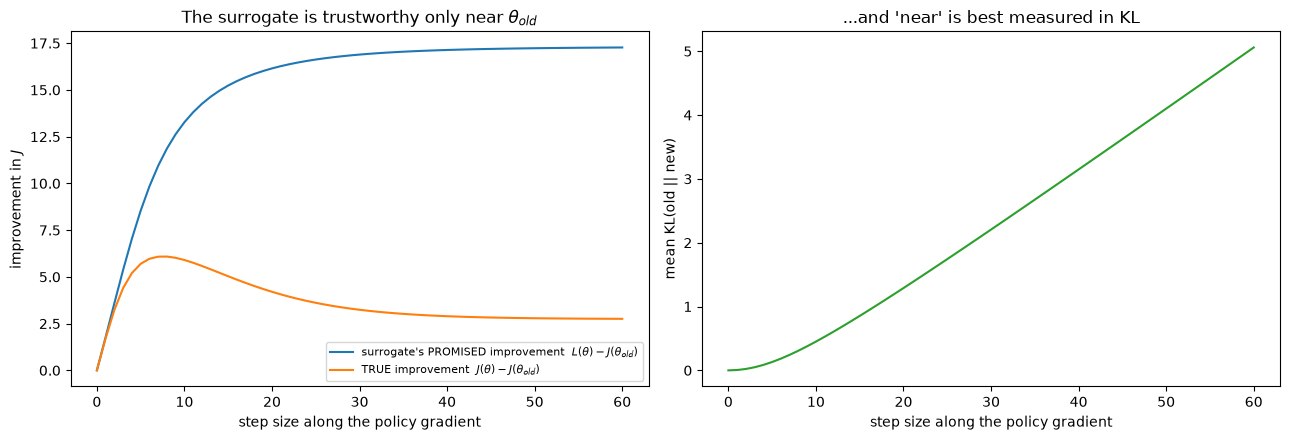

true J peaks at step 8 (KL = 0.31); the surrogate keeps promising more forever.


In [4]:
# ---- Same 4x4 GridWorld as notebooks 1-4, as arrays: NEXT[s, a], REWARD[s, a] ----
H = W = 4; START, GOAL, PIT = (0, 0), (3, 3), (1, 2); GAMMA = 0.95
CELLS = [(r, c) for r in range(H) for c in range(W)]
N_S, N_A = len(CELLS), 4
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]          # up, down, left, right
NEXT = np.zeros((N_S, N_A), dtype=int); REWARD = np.zeros((N_S, N_A))
TERMINAL = np.array([cell in (GOAL, PIT) for cell in CELLS])
for i, (r, c) in enumerate(CELLS):
    for a, (dr, dc) in enumerate(MOVES):
        nr, nc = r + dr, c + dc
        if not (0 <= nr < H and 0 <= nc < W):
            nr, nc = r, c
        NEXT[i, a] = CELLS.index((nr, nc))
        REWARD[i, a] = 10.0 if (nr, nc) == GOAL else (-10.0 if (nr, nc) == PIT else -1.0)

def evaluate_exact(theta):
    '''For a tabular softmax policy theta[s, a]: exact pi, V, A and discounted visitation d.'''
    pi = softmax(theta)
    P, R = np.zeros((N_S, N_S)), np.zeros(N_S)
    for i in range(N_S):
        if TERMINAL[i]:
            continue
        for a in range(N_A):
            P[i, NEXT[i, a]] += pi[i, a]
            R[i] += pi[i, a] * REWARD[i, a]
    M = np.linalg.inv(np.eye(N_S) - GAMMA * P)      # (I - gamma P_pi)^-1
    V = M @ R
    Q = REWARD + GAMMA * V[NEXT]; Q[TERMINAL] = 0.0
    A = Q - V[:, None]
    d = (1 - GAMMA) * M[CELLS.index(START)]          # discounted state visitation from START
    return pi, V, A, d

def J(theta):
    return evaluate_exact(theta)[1][CELLS.index(START)]

def exact_policy_gradient(theta):
    # dJ/dtheta[s,b] = d(s) pi(b|s) A(s,b) / (1-gamma)   (policy gradient theorem, tabular softmax)
    pi, V, A, d = evaluate_exact(theta)
    return d[:, None] * pi * A / (1 - GAMMA)

def surrogate(theta_new, theta_old):
    pi_old, V, A, d = evaluate_exact(theta_old)
    return J(theta_old) + np.sum(d[:, None] * softmax(theta_new) * A) / (1 - GAMMA)

def mean_kl(theta_old, theta_new):
    '''KL(pi_old || pi_new), averaged over the OLD policy's state visitation.'''
    pi_old, _, _, d = evaluate_exact(theta_old)
    pi_new = softmax(theta_new)
    return np.sum(d * np.sum(pi_old * (np.log(pi_old) - np.log(pi_new)), axis=1))

# Sanity check 1: the exact policy gradient matches finite differences of J.
theta0 = np.zeros((N_S, N_A))                        # the uniform random policy
g0 = exact_policy_gradient(theta0)
e = np.zeros_like(theta0); e[4, 1] = 1e-5
fd = (J(theta0 + e) - J(theta0 - e)) / 2e-5
assert abs(fd - g0[4, 1]) < 1e-6
# Sanity check 2: the surrogate's gradient at theta_old equals the policy gradient.
fd_s = (surrogate(theta0 + e, theta0) - surrogate(theta0 - e, theta0)) / 2e-5
assert abs(fd_s - g0[4, 1]) < 1e-6
print("exact PG == finite-difference dJ, and grad of surrogate at theta_old == PG   (verified)")

direction = g0 / np.linalg.norm(g0)
etas = np.linspace(0, 60, 61)
true_gain = [J(theta0 + eta * direction) - J(theta0) for eta in etas]
surr_gain = [surrogate(theta0 + eta * direction, theta0) - J(theta0) for eta in etas]
kls = [mean_kl(theta0, theta0 + eta * direction) for eta in etas]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(etas, surr_gain, label="surrogate's PROMISED improvement  $L(\\theta) - J(\\theta_{old})$")
axes[0].plot(etas, true_gain, label="TRUE improvement  $J(\\theta) - J(\\theta_{old})$")
axes[0].set_xlabel("step size along the policy gradient"); axes[0].set_ylabel("improvement in $J$")
axes[0].set_title("The surrogate is trustworthy only near $\\theta_{old}$"); axes[0].legend(fontsize=8)
axes[1].plot(etas, kls, color="C2")
axes[1].set_xlabel("step size along the policy gradient"); axes[1].set_ylabel("mean KL(old || new)")
axes[1].set_title("...and 'near' is best measured in KL"); plt.tight_layout(); plt.show()

best = etas[int(np.argmax(true_gain))]
print(f"true J peaks at step {best:.0f} (KL = {mean_kl(theta0, theta0 + best * direction):.2f}); "
      f"the surrogate keeps promising more forever.")

The picture every trust-region method is built on:

- For small steps, promised and true improvement agree.
- Past a point, true performance **peaks and then declines**, while the
  surrogate happily promises more and more. An optimizer that maximizes the
  surrogate without restraint walks straight past the peak.
- The disagreement tracks the **KL divergence** between old and new policies.
  TRPO's theory makes this precise: the true improvement is at least the
  surrogate's improvement *minus a penalty proportional to the maximum KL*.
  Keep the KL small and the surrogate is trustworthy.

So we need two things: a proper understanding of KL, and an optimizer that
constrains it.

## 4. KL divergence, from scratch

$$
\mathrm{KL}(p\,\|\,q) = \sum_x p(x)\log\frac{p(x)}{q(x)} = \mathbb E_{x\sim p}\Big[\log\frac{p(x)}{q(x)}\Big] \;\ge\; 0,
$$

with equality iff $p = q$. It measures the extra "surprise" if you believe $q$
while samples actually come from $p$. It's **not symmetric**, and the direction
matters a lot for LLMs, so let's see it rather than just state it.

### Forward vs. reverse KL: mode-covering vs. mode-seeking

Take a **bimodal** target $p$ and fit a single Gaussian $q_{\mu,\sigma}$ to it,
once by minimizing each direction of the KL (a brute-force grid search — no
magic):

- **Forward**, $\min_q \mathrm{KL}(p\|q)$: the expectation is under $p$, so
  wherever $p$ has mass, $q$ must too, or $\log(p/q)$ blows up. $q$ spreads
  out to **cover both modes**.
- **Reverse**, $\min_q \mathrm{KL}(q\|p)$: the expectation is under $q$, so $q$
  pays only where *it* puts mass. It's happy to sit on **one mode** and ignore
  the other entirely.

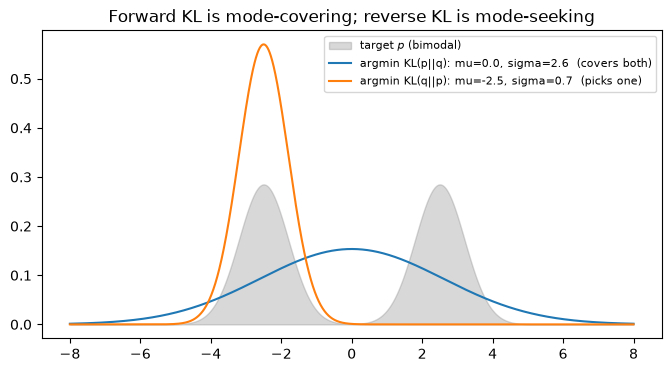

In [5]:
xs = np.linspace(-8, 8, 2001); dx = xs[1] - xs[0]
def gauss(x, mu, s):
    return np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))
p = 0.5 * gauss(xs, -2.5, 0.7) + 0.5 * gauss(xs, 2.5, 0.7)

def kl(a, b):
    return np.sum(a * (np.log(a + 1e-300) - np.log(b + 1e-300))) * dx

best_fwd, best_rev = (np.inf, None), (np.inf, None)
for mu in np.linspace(-4, 4, 81):
    for s in np.linspace(0.3, 4, 75):
        q = gauss(xs, mu, s)
        best_fwd = min(best_fwd, (kl(p, q), (mu, s)), key=lambda t: t[0])
        best_rev = min(best_rev, (kl(q, p), (mu, s)), key=lambda t: t[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(xs, p, alpha=0.3, color="gray", label="target $p$ (bimodal)")
ax.plot(xs, gauss(xs, *best_fwd[1]), label=f"argmin KL(p||q): mu={best_fwd[1][0]:.1f}, sigma={best_fwd[1][1]:.1f}  (covers both)")
ax.plot(xs, gauss(xs, *best_rev[1]), label=f"argmin KL(q||p): mu={best_rev[1][0]:.1f}, sigma={best_rev[1][1]:.1f}  (picks one)")
ax.set_title("Forward KL is mode-covering; reverse KL is mode-seeking"); ax.legend(fontsize=8); plt.show()

Why this matters for LLMs: RLHF penalizes $\mathrm{KL}(\pi_\theta \,\|\, \pi_{\text{ref}})$ with
samples from the policy $\pi_\theta$ — the **reverse**, mode-seeking direction.
That penalty stops the policy from putting mass where the reference model
wouldn't. It does **not** force the policy to keep covering *everything* the
reference model could say. Loss of diversity after RL fine-tuning is partly
a direct consequence of this asymmetry.

### Estimating KL from samples: k1, k2, k3

For an LLM we can't sum over all sequences. We can only sample
$x\sim q$ (from the current policy) and evaluate both log-probabilities. With
$r = p(x)/q(x)$ (here $p$ = reference, $q$ = policy), and estimating
$\mathrm{KL}(q\|p) = \mathbb E_q[-\log r]$, three estimators are in common use
(named in John Schulman's note *Approximating KL Divergence*):

| name | per-sample estimate | unbiased? | variance | can be negative? |
|---|---|---|---|---|
| **k1** | $-\log r$ | yes | high | **yes** (single samples often are) |
| **k2** | $\tfrac12(\log r)^2$ | no (but close when $p\approx q$) | low | no |
| **k3** | $(r - 1) - \log r$ | **yes** | low | **no** — always $\ge 0$ |

Why is k3 unbiased? $\mathbb E_q[r - 1] = \sum_x q\,\tfrac{p}{q} - 1 = 0$, so adding
$(r-1)$ doesn't change the mean. And $(r-1) - \log r \ge 0$ because
$\log r \le r - 1$. It's a **control variate**: a zero-mean term that cancels
much of k1's noise. k1 appears as the per-token KL penalty in PPO-based RLHF.
k3 is what **GRPO** uses (notebook 9), and it's also PPO's standard
`approx_kl` diagnostic (Section 6). Let's check the claims.

In [6]:
rng = np.random.default_rng(0)
vocab = 20
q_logits = rng.normal(size=vocab)
print(f"{'how far p is from q':>20} | {'true KL(q||p)':>13} | {'k1 mean/std':>15} | {'k2 mean/std':>15} | {'k3 mean/std':>15} | {'% k1 < 0':>8}")
for shift in [0.1, 0.5, 1.0]:
    p_logits = q_logits + shift * rng.normal(size=vocab)
    q_, p_ = softmax(q_logits), softmax(p_logits)
    true_kl = np.sum(q_ * np.log(q_ / p_))
    x = rng.choice(vocab, size=200_000, p=q_)
    log_r = np.log(p_[x]) - np.log(q_[x])
    k1, k2, k3 = -log_r, 0.5 * log_r ** 2, np.exp(log_r) - 1 - log_r
    print(f"{shift:>20} | {true_kl:>13.4f} | {k1.mean():>7.4f}/{k1.std():<7.3f} | {k2.mean():>7.4f}/{k2.std():<7.3f} | "
          f"{k3.mean():>7.4f}/{k3.std():<7.3f} | {100 * np.mean(k1 < 0):>7.1f}%")
    assert abs(k1.mean() - true_kl) < 0.01 and abs(k3.mean() - true_kl) < 0.01   # unbiased (within sampling error)
print("k1 and k3 are unbiased; k3 has far lower variance and is never negative.")

 how far p is from q | true KL(q||p) |     k1 mean/std |     k2 mean/std |     k3 mean/std | % k1 < 0
                 0.1 |        0.0035 |  0.0039/0.083   |  0.0035/0.003   |  0.0035/0.003   |    44.2%
                 0.5 |        0.0969 |  0.0949/0.446   |  0.1038/0.088   |  0.0968/0.081   |    48.7%
                 1.0 |        0.3019 |  0.3013/0.809   |  0.3730/0.558   |  0.3018/0.329   |    25.4%
k1 and k3 are unbiased; k3 has far lower variance and is never negative.


## 5. TRPO: step a fixed distance in *distribution* space

We now have the ingredients for a principled update:

$$
\max_\theta\; L_{\theta_{\text{old}}}(\theta) \quad\text{subject to}\quad \bar{\mathrm{KL}}(\theta_{\text{old}}, \theta) \le \delta,
$$

where $\bar{\mathrm{KL}}$ is the KL averaged over visited states. "Improve as much as
the surrogate promises, but only within a region where we trust the
surrogate." This is **Trust Region Policy Optimization** (Schulman et al.,
2015).

### Solving it: second-order approximation, natural gradient

Expand both sides around $\theta_{\text{old}}$, with $\Delta = \theta - \theta_{\text{old}}$:

- Surrogate, to first order: $L \approx L(\theta_{\text{old}}) + g^\top\Delta$, where $g$ is
  the policy gradient (Section 3).
- KL, to second order: $\bar{\mathrm{KL}} \approx \tfrac12 \Delta^\top F \Delta$. The zeroth- and
  first-order terms vanish because KL is minimized (at 0) at $\Delta = 0$. $F$ is
  the Hessian of the KL, which turns out to equal the **Fisher information
  matrix** $F = \mathbb E\big[\nabla\log\pi\,\nabla\log\pi^\top\big]$.

Maximize $g^\top\Delta$ subject to $\tfrac12\Delta^\top F\Delta \le \delta$ with a Lagrange multiplier:
the solution points along $F^{-1}g$, scaled to sit exactly on the boundary:

$$
\Delta^\star = \sqrt{\frac{2\delta}{g^\top F^{-1} g}}\; F^{-1} g .
$$

$F^{-1}g$ is the **natural gradient**. It's the steepest-ascent direction when
distance is measured by KL (how much *behavior* changes) rather than by
Euclidean distance in parameter space. For a softmax, some parameter
directions barely change the distribution (e.g. pushing an already-saturated
logit further), and others change it enormously. $F^{-1}$ rescales them all
to be comparable.

### Making it practical: conjugate gradient + line search

For a neural network, $F$ is $n \times n$ with $n$ in the millions, so we can
never form or invert it. **Conjugate gradient** (CG) solves $Fx = g$ using
only matrix-vector products $Fv$, which can be computed without ever building
$F$. Here the policy is small enough to build $F$ explicitly, but we still
use CG, exactly as TRPO does. Finally, because both approximations above are
only approximations, TRPO does a **backtracking line search**: shrink the step
until the *actual* KL is within budget and the surrogate *actually* improves.

For a tabular softmax policy, $F$ is block-diagonal: one block per state,
$d(s)\big(\mathrm{diag}(\pi_s) - \pi_s\pi_s^\top\big)$. Everything is exact here, so we can
compare **vanilla policy gradient** at several learning rates against **TRPO**
at several KL budgets.

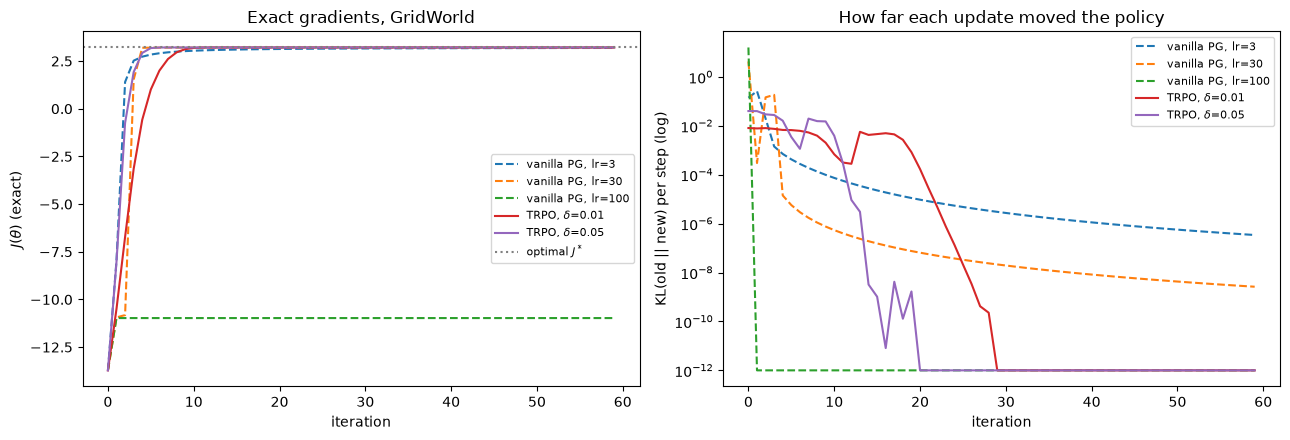

In [7]:
def fisher_matrix(theta):
    pi, _, _, d = evaluate_exact(theta)
    F = np.zeros((N_S * N_A, N_S * N_A))
    for s in range(N_S):
        p = pi[s]
        F[s * N_A:(s + 1) * N_A, s * N_A:(s + 1) * N_A] = d[s] * (np.diag(p) - np.outer(p, p))
    return F

def conjugate_gradient(matvec, b, iters=50, tol=1e-10):
    '''Solve A x = b for symmetric positive-definite A, touching A only through matvec(v) = A v.'''
    x = np.zeros_like(b); r = b.copy(); p = r.copy(); rs = r @ r
    for _ in range(iters):
        Ap = matvec(p)
        alpha = rs / (p @ Ap)
        x += alpha * p; r -= alpha * Ap
        rs_new = r @ r
        if rs_new < tol:
            break
        p = r + (rs_new / rs) * p; rs = rs_new
    return x

def trpo_step(theta, delta, damping=1e-3):
    g = (exact_policy_gradient(theta) * (1 - GAMMA)).ravel()     # gradient of the surrogate (per-visit scale)
    F = fisher_matrix(theta)
    matvec = lambda v: F @ v + damping * v                      # damping: F is singular for softmax
    x = conjugate_gradient(matvec, g)                           # x = F^-1 g, the natural gradient
    full_step = np.sqrt(2 * delta / (x @ matvec(x))) * x
    L_old = surrogate(theta, theta)
    for frac in 0.5 ** np.arange(10):                           # backtracking line search
        theta_new = theta + frac * full_step.reshape(N_S, N_A)
        if mean_kl(theta, theta_new) <= 1.5 * delta and surrogate(theta_new, theta) > L_old:
            return theta_new
    return theta

def run(update, n_iters=60):
    theta = np.zeros((N_S, N_A)); Js, KLs = [], []
    for _ in range(n_iters):
        Js.append(J(theta))
        theta_new = update(theta)
        KLs.append(mean_kl(theta, theta_new)); theta = theta_new
    return np.array(Js), np.array(KLs)

J_star = run(lambda th: trpo_step(th, 0.05), 200)[0][-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lr in [3, 30, 100]:
    Js, KLs = run(lambda th, lr=lr: th + lr * exact_policy_gradient(th))
    axes[0].plot(Js, "--", label=f"vanilla PG, lr={lr}"); axes[1].semilogy(KLs + 1e-12, "--", label=f"vanilla PG, lr={lr}")
for delta in [0.01, 0.05]:
    Js, KLs = run(lambda th, delta=delta: trpo_step(th, delta))
    axes[0].plot(Js, label=f"TRPO, $\\delta$={delta}"); axes[1].semilogy(KLs + 1e-12, label=f"TRPO, $\\delta$={delta}")
axes[0].axhline(J_star, color="gray", ls=":", label="optimal $J^*$")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("$J(\\theta)$ (exact)"); axes[0].legend(fontsize=8)
axes[0].set_title("Exact gradients, GridWorld")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("KL(old || new) per step (log)")
axes[1].set_title("How far each update moved the policy"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Even with **perfect, noise-free gradients**:

- Vanilla PG with a small learning rate is slow. With a larger one it can take
  a huge first step that shoves the policy toward the pit (look at how far
  the $J$ curve dips) and later recover — or, with a still larger rate,
  **collapse into a deterministic bad policy and never recover**, exactly
  notebook 5's failure. The right-hand plot shows why: the same learning rate
  produces wildly different KL per step at different points in training.
- TRPO's per-step KL stays pinned near the budget $\delta$ for as long as there
  is something to learn, then shrinks on its own as the policy converges
  (the gradient vanishes and the line search takes smaller steps). You
  choose *how much behavior may change per update*, which is interpretable and
  stable across problems, instead of a learning rate whose effect changes as
  training progresses.

TRPO works, and it's principled. It's also complicated: CG, Fisher-vector
products, a line search, and awkward to combine with shared actor-critic
networks, dropout, or huge models. Could we get most of the benefit with a
plain first-order optimizer like Adam?

## 6. PPO: a trust region you can implement in ten lines

**Proximal Policy Optimization** (Schulman et al., 2017) replaces the hard KL
constraint with a modified objective that simply **stops rewarding the policy
for moving the ratio too far**. With $\rho_t(\theta) = \pi_\theta(a_t\mid s_t)/\pi_{\text{old}}(a_t\mid s_t)$:

$$
L^{\text{CLIP}}(\theta) = \mathbb E_t\Big[\min\Big(\rho_t\,\hat A_t,\;\; \mathrm{clip}(\rho_t,\,1-\epsilon,\,1+\epsilon)\,\hat A_t\Big)\Big], \qquad \epsilon \approx 0.2 .
$$

### Reading the objective case by case

- **$\hat A_t > 0$ (a good action — we want to increase $\rho_t$).** The objective
  grows with $\rho_t$ only until $\rho_t = 1+\epsilon$, then goes flat. Once the action
  is already 20% more likely than under the old policy, there's **no further
  incentive** from this sample.
- **$\hat A_t < 0$ (a bad action — we want to decrease $\rho_t$).** The objective
  improves as $\rho_t$ falls, but only until $1-\epsilon$, then goes flat.
- **Why the `min`?** It makes the objective a **pessimistic bound**. If an
  update has *accidentally* moved $\rho_t$ the wrong way — say, a bad action
  became more likely, $\rho_t > 1$ with $\hat A_t < 0$ — the unclipped term
  $\rho_t\hat A_t$ is the smaller (more negative) of the two, so the `min` keeps
  it and the gradient keeps pushing back. Clipping only ever removes the
  *incentive to go further*, never the *penalty for going the wrong way*.

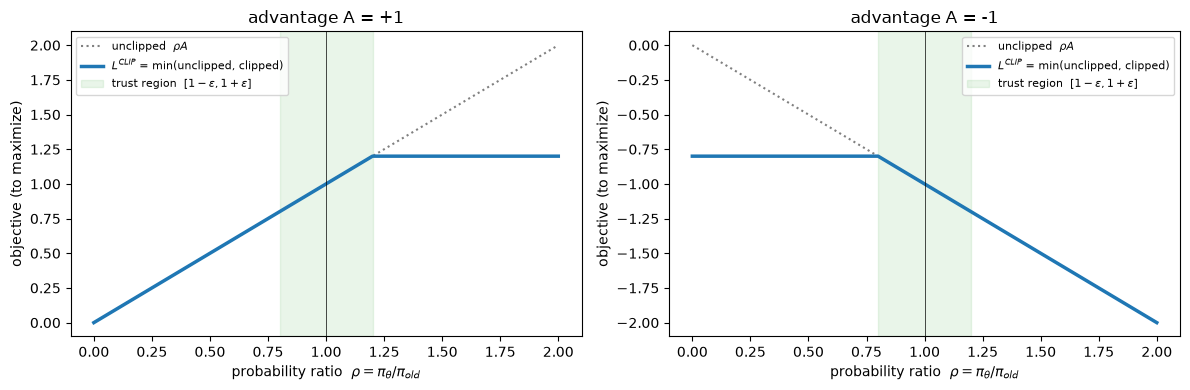

In [8]:
rho = np.linspace(0, 2, 401); eps = 0.2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, A in zip(axes, [1.0, -1.0]):
    unclipped = rho * A
    clipped = np.clip(rho, 1 - eps, 1 + eps) * A
    ax.plot(rho, unclipped, ":", color="gray", label="unclipped  $\\rho A$")
    ax.plot(rho, np.minimum(unclipped, clipped), lw=2.5, label="$L^{CLIP}$ = min(unclipped, clipped)")
    ax.axvspan(1 - eps, 1 + eps, alpha=0.1, color="C2", label="trust region  $[1-\\epsilon, 1+\\epsilon]$")
    ax.axvline(1, color="k", lw=0.5)
    ax.set_xlabel("probability ratio  $\\rho = \\pi_\\theta / \\pi_{old}$"); ax.set_ylabel("objective (to maximize)")
    ax.set_title(f"advantage A = {A:+.0f}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### The gradient, by hand

Since $\nabla_\theta\rho_t = \rho_t\,\nabla_\theta\log\pi_\theta(a_t\mid s_t)$, and for a softmax
$\nabla_{\text{logits}}\log\pi(a) = \text{onehot}(a) - \pi$ (notebook 5):

$$
\nabla_{\text{logits}} L^{\text{CLIP}}_t =
\begin{cases}
0 & \text{if } (\hat A_t > 0 \text{ and } \rho_t > 1+\epsilon) \text{ or } (\hat A_t < 0 \text{ and } \rho_t < 1-\epsilon) \quad\text{(clipped: flat)}\\[2pt]
\hat A_t\,\rho_t\,\big(\text{onehot}(a_t) - \pi_\theta(\cdot\mid s_t)\big) & \text{otherwise}
\end{cases}
$$

It's notebook 5's policy gradient, reweighted by $\rho_t$ (the importance
correction), and **switched off per sample** once that sample has moved the
policy far enough in the direction it wanted. We verify this by finite
differences before trusting it.

In [9]:
def ppo_clip_logit_grad(logits, actions, adv, old_logp, clip_eps, ent_coef=0.0):
    '''dLoss/dlogits for loss = -mean(min(rho*A, clip(rho)*A)) - ent_coef*mean(entropy).'''
    p = softmax(logits); B = len(actions)
    logp = np.log(p[np.arange(B), actions])
    rho = np.exp(logp - old_logp)
    clipped = ((adv > 0) & (rho > 1 + clip_eps)) | ((adv < 0) & (rho < 1 - clip_eps))
    coef = np.where(clipped, 0.0, adv * rho)
    d = -(coef[:, None] * (np.eye(p.shape[1])[actions] - p)) / B
    logp_all = np.log(p + 1e-12)
    Hs = -(p * logp_all).sum(axis=1, keepdims=True)
    d -= ent_coef * (-p * (logp_all + Hs)) / B
    return d, rho, clipped

def ppo_clip_loss(logits, actions, adv, old_logp, clip_eps):
    p = softmax(logits); B = len(actions)
    rho = np.exp(np.log(p[np.arange(B), actions]) - old_logp)
    return -np.mean(np.minimum(rho * adv, np.clip(rho, 1 - clip_eps, 1 + clip_eps) * adv))

# finite-difference check, with ratios deliberately spread across clipped and unclipped regions
rng = np.random.default_rng(0)
B = 12
logits = rng.normal(size=(B, 2)); actions = rng.integers(2, size=B); adv = rng.normal(size=B)
old_logp = np.log(softmax(logits)[np.arange(B), actions]) + rng.normal(0, 0.3, size=B)
d_analytic, rho_chk, clipped_chk = ppo_clip_logit_grad(logits, actions, adv, old_logp, 0.2)
d_numeric = np.zeros_like(logits)
for i in range(B):
    for j in range(2):
        e = np.zeros_like(logits); e[i, j] = 1e-6
        d_numeric[i, j] = (ppo_clip_loss(logits + e, actions, adv, old_logp, 0.2)
                           - ppo_clip_loss(logits - e, actions, adv, old_logp, 0.2)) / 2e-6
print(f"{clipped_chk.sum()} of {B} samples are in the clipped (zero-gradient) region")
print(f"max |analytic - numeric| = {np.abs(d_analytic - d_numeric).max():.2e}")
assert np.allclose(d_analytic, d_numeric, atol=1e-6)

5 of 12 samples are in the clipped (zero-gradient) region
max |analytic - numeric| = 1.76e-11


## 7. Full PPO on CartPole

Here is the whole algorithm. Every piece was built in notebooks 4–6:

```
repeat:
    1. roll out the current policy for N steps           -> states, actions, rewards, old log-probs
    2. critic values -> GAE advantages & returns           (notebook 5, lambda = 0.95)
    3. for K epochs:                                       <- the whole point: reuse the batch
         for each random minibatch:
             normalize advantages (per minibatch)
             actor  step on  -L^CLIP  (- entropy bonus)    (Section 6)
             critic step on  (V(s) - return)^2            (notebook 4)
    4. log diagnostics: approx-KL (k3!), clip fraction
```

Two diagnostics are worth watching in any PPO run, including LLM runs:

- **approx_kl**: the k3 estimate (Section 4) of $\mathrm{KL}(\pi_{\text{old}}\|\pi_\theta)$
  after the update. It tells you how far the policy actually moved. PPO
  doesn't *constrain* KL directly — clipping is a proxy for that — so this is
  your check that the trust region is holding.
- **clip_fraction**: the fraction of samples whose gradient was switched off.
  Near 0 means the clip isn't doing anything. Very high means the updates are
  trying to move much further than $\epsilon$ allows.

We'll run three configurations on identical batches of 2048 steps:

1. **A2C** — notebook 5's actor-critic: one gradient step per batch.
2. **PPO** — 10 epochs × 32 minibatches per batch, with clipping.
3. **PPO without clipping** — the same 10 epochs of reuse, but $\epsilon = \infty$:
   plain importance-weighted policy gradient. This ablation isolates exactly
   what clipping buys.

9 training runs in 3369s


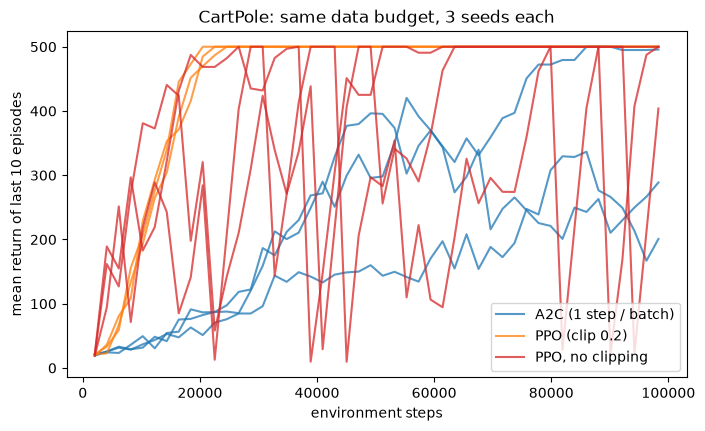

  A2C (1 step / batch): steps to first reach >=475: [None, None, 81920];  worst return in 2nd half of training: [200, 134, 302]
        PPO (clip 0.2): steps to first reach >=475: [22528, 20480, 20480];  worst return in 2nd half of training: [500, 500, 500]
      PPO, no clipping: steps to first reach >=475: [47104, 18432, 28672];  worst return in 2nd half of training: [22, 490, 22]


In [10]:
def collect_rollout(env, actor, n_steps, rng, carry):
    s, ep_ret, finished = carry
    buf = {k: [] for k in ["s", "a", "r", "s_next", "term", "end", "logp"]}
    for t in range(n_steps):
        p = softmax(actor.predict(s[None])[0])
        a = rng.choice(2, p=p)
        s_next, r, terminated, truncated = env.step(a)
        ep_ret += r
        for k, v in zip(buf, [s, a, r, s_next, float(terminated),
                              float(terminated or truncated or t == n_steps - 1), np.log(p[a])]):
            buf[k].append(v)
        if terminated or truncated:
            finished.append(ep_ret); ep_ret = 0.0; s = env.reset()
        else:
            s = s_next
    out = {k: np.array(v) for k, v in buf.items()}
    out["a"] = out["a"].astype(int)
    return out, (s, ep_ret, finished)


def ppo(total_steps=100_000, n_steps=2048, epochs=10, minibatch=64, lr=3e-4, critic_lr=1e-3,
        clip_eps=0.2, gamma=0.99, lam=0.95, ent_coef=0.0, max_grad_norm=0.5, seed=0):
    rng = np.random.default_rng(seed)
    env = CartPole(seed=seed)
    actor = MLP([4, 64, 64, 2], "tanh", out_scale=0.01, seed=seed)
    critic = MLP([4, 64, 64, 1], "tanh", seed=seed + 1000)
    a_opt, c_opt = Adam(actor.params, lr=lr), Adam(critic.params, lr=critic_lr)
    carry = (env.reset(), 0.0, [])
    log = {"step": [], "return": [], "approx_kl": [], "clip_frac": []}

    for it in range(total_steps // n_steps):
        b, carry = collect_rollout(env, actor, n_steps, rng, carry)                  # 1. rollout
        V = critic.predict(b["s"])[:, 0]; V_next = critic.predict(b["s_next"])[:, 0]
        adv, returns = compute_gae(b["r"], V, V_next, b["term"], b["end"], gamma, lam)  # 2. GAE

        clip_flags = []
        for _ in range(epochs):                                                      # 3. K epochs
            perm = rng.permutation(n_steps)
            for start in range(0, n_steps, minibatch):
                idx = perm[start:start + minibatch]
                mb_adv = (adv[idx] - adv[idx].mean()) / (adv[idx].std() + 1e-8)
                logits, cache = actor.forward(b["s"][idx])
                d, _, clipped = ppo_clip_logit_grad(logits, b["a"][idx], mb_adv, b["logp"][idx], clip_eps, ent_coef)
                a_opt.step(actor.backward(cache, d), max_norm=max_grad_norm)
                v_out, v_cache = critic.forward(b["s"][idx])
                c_opt.step(critic.backward(v_cache, (v_out[:, 0] - returns[idx])[:, None] / len(idx)), max_norm=max_grad_norm)
                clip_flags.append(clipped.mean())

        # 4. diagnostics: k3 estimate of KL(old || new) on the whole batch
        p_new = softmax(actor.predict(b["s"]))[np.arange(n_steps), b["a"]]
        log_r = np.log(p_new) - b["logp"]            # log(pi_new / pi_old), samples from pi_old
        fin = carry[2]
        log["step"].append((it + 1) * n_steps)
        log["return"].append(np.mean(fin[-10:]) if fin else 0.0)
        log["approx_kl"].append(np.mean(np.exp(log_r) - 1 - log_r))
        log["clip_frac"].append(np.mean(clip_flags))
    return log


def a2c(total_steps=100_000, n_steps=2048, lr=3e-3, critic_lr=3e-3, gamma=0.99, lam=0.95, seed=0):
    '''Notebook 5's actor-critic: ONE full-batch gradient step per rollout.'''
    rng = np.random.default_rng(seed)
    env = CartPole(seed=seed)
    actor = MLP([4, 64, 64, 2], "tanh", out_scale=0.01, seed=seed)
    critic = MLP([4, 64, 64, 1], "tanh", seed=seed + 1000)
    a_opt, c_opt = Adam(actor.params, lr=lr), Adam(critic.params, lr=critic_lr)
    carry = (env.reset(), 0.0, []); log = {"step": [], "return": []}
    for it in range(total_steps // n_steps):
        b, carry = collect_rollout(env, actor, n_steps, rng, carry)
        V = critic.predict(b["s"])[:, 0]; V_next = critic.predict(b["s_next"])[:, 0]
        adv, returns = compute_gae(b["r"], V, V_next, b["term"], b["end"], gamma, lam)
        logits, cache = actor.forward(b["s"])
        d, _, _ = ppo_clip_logit_grad(logits, b["a"], adv, b["logp"], np.inf)   # rho = 1 exactly -> plain PG
        a_opt.step(actor.backward(cache, d))
        v_out, v_cache = critic.forward(b["s"])
        c_opt.step(critic.backward(v_cache, (v_out[:, 0] - returns)[:, None] / n_steps))
        fin = carry[2]
        log["step"].append((it + 1) * n_steps); log["return"].append(np.mean(fin[-10:]) if fin else 0.0)
    return log

t0 = time.time()
runs = {
    "A2C (1 step / batch)": [a2c(seed=s) for s in range(3)],
    "PPO (clip 0.2)": [ppo(seed=s) for s in range(3)],
    "PPO, no clipping": [ppo(clip_eps=np.inf, seed=s) for s in range(3)],
}
print(f"9 training runs in {time.time() - t0:.0f}s")

fig, ax = plt.subplots(figsize=(8, 4.5))
for (name, logs), color in zip(runs.items(), ["C0", "C1", "C3"]):
    for i, lg in enumerate(logs):
        ax.plot(lg["step"], lg["return"], color=color, alpha=0.75, label=name if i == 0 else None)
ax.set_xlabel("environment steps"); ax.set_ylabel("mean return of last 10 episodes")
ax.set_title("CartPole: same data budget, 3 seeds each"); ax.legend(); plt.show()

for name, logs in runs.items():
    first500 = [next((st for st, r in zip(lg["step"], lg["return"]) if r >= 475), None) for lg in logs]
    worst_late = [min(lg["return"][len(lg["return"]) // 2:]) for lg in logs]
    print(f"{name:>22}: steps to first reach >=475: {first500};  worst return in 2nd half of training: {[int(w) for w in worst_late]}")

What the curves show (check them against the printed numbers):

- **PPO vs. A2C: reuse pays off.** PPO reaches the maximum score in roughly
  20k environment steps on every seed. Within the same 100k-step budget, A2C
  gets there on at most one seed. PPO extracts ~320 gradient steps from every
  batch instead of 1. In LLM terms: far fewer
  expensive generation rounds for the same improvement.
- **Clipping vs. no clipping: stability.** Without clipping, the same data
  reuse also learns quickly at first, then **repeatedly crashes**, sometimes
  all the way back to random-policy performance. Ten epochs of unconstrained
  importance-weighted updates walk the policy far outside the region where
  the surrogate is trustworthy — Section 3's plot, happening live. With
  clipping, once the policy reaches 500 it stays there.

Now the diagnostics, which are how you'd *detect* this in a real run:

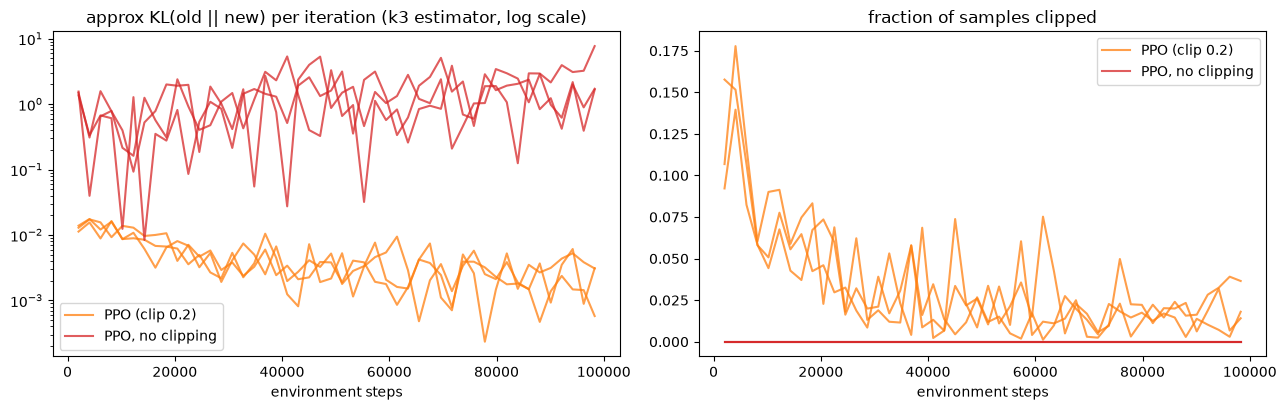

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for (name, logs), color in zip([(k, v) for k, v in runs.items() if k.startswith("PPO")], ["C1", "C3"]):
    for i, lg in enumerate(logs):
        axes[0].semilogy(lg["step"], np.maximum(lg["approx_kl"], 1e-6), color=color, alpha=0.75, label=name if i == 0 else None)
        axes[1].plot(lg["step"], lg["clip_frac"], color=color, alpha=0.75, label=name if i == 0 else None)
axes[0].set_title("approx KL(old || new) per iteration (k3 estimator, log scale)")
axes[1].set_title("fraction of samples clipped")
for ax in axes:
    ax.set_xlabel("environment steps"); ax.legend()
plt.tight_layout(); plt.show()

With clipping, the per-iteration KL stays small and steady. Without it, the
KL is typically much larger and spikier, and those spikes line up with the
crashes in the learning curve. (The "clip fraction" of the unclipped run is 0
by construction: it's measuring a clip that isn't there.) In real LLM
training, **a sudden jump in approx_kl or clip fraction is one of the first
signs that a run is about to diverge.**

## 8. PPO with a KL penalty to a reference model — the RLHF recipe

Everything so far constrains how far the policy moves **per update**
(old → new). LLM fine-tuning adds a second, different constraint: how far the
policy may drift **in total** from the model we started with, the
**reference model** $\pi_{\text{ref}}$ (the SFT model). The objective becomes

$$
\max_\theta\;\; \mathbb E_{y\sim\pi_\theta}\big[r(y)\big] \;-\; \beta\,\mathrm{KL}\big(\pi_\theta \,\|\, \pi_{\text{ref}}\big).
$$

Why? The reward $r$ usually comes from a **learned reward model** — an
imperfect function approximator (notebook 4's lesson: *optimizing against an
estimate exploits its errors*). Left unchecked, the policy finds outputs the
reward model *overrates*: gibberish, repetition, sycophancy. That's **reward
hacking**. The KL term says: stay close to the model that still writes like a
sensible language model, unless the reward really justifies moving.

### The optimum has a closed form

For a bandit-style objective over whole sequences $y$, maximize
$\sum_y \pi(y) r(y) - \beta\sum_y \pi(y)\log\frac{\pi(y)}{\pi_{\text{ref}}(y)}$ subject to
$\sum_y\pi(y) = 1$. With a Lagrange multiplier $\eta$, setting the derivative with
respect to $\pi(y)$ to zero gives
$r(y) - \beta\big(\log\tfrac{\pi(y)}{\pi_{\text{ref}}(y)} + 1\big) - \eta = 0$, so

$$
\boxed{\;\pi^{*}(y) = \frac{1}{Z}\,\pi_{\text{ref}}(y)\,\exp\!\big(r(y)/\beta\big)\;}
$$

— the reference model, **reweighted by exponentiated reward**. $\beta$ is the
temperature: $\beta\to\infty$ keeps $\pi_{\text{ref}}$, and $\beta\to 0$ puts all mass on
the reward-maximizing sequence. Hold on to this formula. It's the exact
equation **DPO** (notebook 10) inverts to turn preference data into a
supervised loss, and it describes the policy that **RLCD** (notebook 11)
produces from its contrastively-generated preference pairs.

### The experiment

- **Reference model** $\pi_{\text{ref}}$: our 3-token {A, B, C} generator from
  notebooks 1 and 5, with fixed "pretrained" logits that make "C" fairly
  unlikely. It generates "CCC" only ~1% of the time.
- **Reward model** with a quirk: $r(y)$ = number of "C" tokens in $y$. Think of
  "C" as a phrase the reward model overrates — the hackable direction.
- **Training**: PPO-clip on per-token ratios. The sequence-level reward
  includes the KL penalty as $r(y) - \beta\sum_t\log\frac{\pi_{\text{old}}(y_t\mid y_{<t})}{\pi_{\text{ref}}(y_t\mid y_{<t})}$
  (the **k1** estimator, summed over tokens), and every token of a sequence
  shares its leave-one-out advantage (notebook 5). This is structurally the
  same as PPO for RLHF, with the bandit-style advantage used by RLOO/GRPO.

Because there are only 27 possible sequences, we can compute the learned
distribution **exactly**, compare it against $\pi^{*}$ for each $\beta$, and check
that the algorithm lands on the theoretical optimum.

In [12]:
VOCAB = ["A", "B", "C"]
PREFIXES = [()] + [(a,) for a in range(3)] + [(a, b) for a in range(3) for b in range(3)]
SEQUENCES = list(itertools.product(range(3), repeat=3))           # all 27 completions
rng = np.random.default_rng(0)
REF_LOGITS = {pre: rng.normal(0, 1, 3) + np.array([0.5, 0.5, -1.0]) for pre in PREFIXES}   # "pretrained", dislikes C
RM_SCORE = np.array([sum(tok == 2 for tok in y) for y in SEQUENCES], dtype=float)          # quirk: loves "C"

def seq_logprob(logits, y):
    return sum(np.log(softmax(logits[y[:t]])[y[t]]) for t in range(len(y)))

def sequence_distribution(logits):
    return np.array([np.exp(seq_logprob(logits, y)) for y in SEQUENCES])

def to_text(y):
    return "".join(VOCAB[t] for t in y)

p_ref = sequence_distribution(REF_LOGITS)
print(f"reference model: P('CCC') = {p_ref[-1]:.3f}, expected reward-model score = {p_ref @ RM_SCORE:.3f}")
top = np.argsort(-p_ref)[:5]
print("reference model's 5 most likely completions:", [(to_text(SEQUENCES[i]), round(p_ref[i], 3)) for i in top])

reference model: P('CCC') = 0.010, expected reward-model score = 0.375
reference model's 5 most likely completions: [('AAB', np.float64(0.214)), ('BAA', np.float64(0.172)), ('BBA', np.float64(0.098)), ('ABB', np.float64(0.064)), ('ABA', np.float64(0.053))]


In [13]:
def rlhf_ppo(beta, n_iters=300, batch=64, epochs=4, lr=0.5, clip_eps=0.2, seed=0):
    rng = np.random.default_rng(seed)
    logits = {pre: REF_LOGITS[pre].copy() for pre in PREFIXES}     # start FROM the reference model
    history = []
    for _ in range(n_iters):
        # 1. generate a batch of completions with the current policy
        ys = []
        for _ in range(batch):
            y = ()
            for _ in range(3):
                y = y + (rng.choice(3, p=softmax(logits[y])),)
            ys.append(y)
        old_lp = np.array([[np.log(softmax(logits[y[:t]])[y[t]]) for t in range(3)] for y in ys])
        ref_lp = np.array([[np.log(softmax(REF_LOGITS[y[:t]])[y[t]]) for t in range(3)] for y in ys])
        # 2. KL-penalized sequence reward, then leave-one-out advantage
        R = np.array([RM_SCORE[SEQUENCES.index(y)] for y in ys]) - beta * (old_lp - ref_lp).sum(axis=1)
        A = R - (R.sum() - R) / (batch - 1)
        # 3. several PPO-clip epochs on per-token ratios
        for _ in range(epochs):
            grads = {pre: np.zeros(3) for pre in PREFIXES}
            for i, y in enumerate(ys):
                for t in range(3):
                    p = softmax(logits[y[:t]])
                    rho = p[y[t]] / np.exp(old_lp[i, t])
                    clipped = (A[i] > 0 and rho > 1 + clip_eps) or (A[i] < 0 and rho < 1 - clip_eps)
                    if not clipped:
                        grads[y[:t]] += A[i] * rho * (np.eye(3)[y[t]] - p)
            for pre in PREFIXES:
                logits[pre] += lr * grads[pre] / batch
        q = sequence_distribution(logits)
        history.append((q @ RM_SCORE, np.sum(q * np.log(q / p_ref))))
    return logits, np.array(history)

def optimal_policy(beta):
    w = p_ref * np.exp(RM_SCORE / beta)
    return w / w.sum()

t0 = time.time()
betas = [0.1, 0.3, 1.0, 3.0]
learned = {beta: rlhf_ppo(beta) for beta in betas}
print(f"trained 4 policies in {time.time() - t0:.0f}s\n")
print(f"{'beta':>5} | {'E[RM score]':>11} | {'KL(pi||ref)':>11} | {'P(CCC)':>7} | {'TV(learned, pi*)':>16} | 5 sample completions")
rng = np.random.default_rng(42)
for beta in betas:
    q = sequence_distribution(learned[beta][0])
    tv = 0.5 * np.abs(q - optimal_policy(beta)).sum()
    kl_ref = np.sum(q * np.log(q / p_ref))
    samples = [to_text(SEQUENCES[i]) for i in rng.choice(27, size=5, p=q)]
    print(f"{beta:>5} | {q @ RM_SCORE:>11.3f} | {kl_ref:>11.3f} | {q[-1]:>7.3f} | {tv:>16.3f} | {samples}")
    assert tv < 0.1, "PPO should land (close to) on the closed-form KL-regularized optimum"
print("\nEvery learned policy matches pi*(y) = pi_ref(y) exp(r(y)/beta) / Z  (total-variation distance < 0.1).")

trained 4 policies in 911s

 beta | E[RM score] | KL(pi||ref) |  P(CCC) | TV(learned, pi*) | 5 sample completions
  0.1 |       2.992 |       4.560 |   0.995 |            0.005 | ['CCC', 'CCC', 'CCC', 'CCC', 'CCC']
  0.3 |       2.812 |       3.814 |   0.849 |            0.031 | ['CCC', 'CCC', 'CCC', 'CCB', 'CCC']
  1.0 |       1.033 |       0.377 |   0.104 |            0.001 | ['BAA', 'CCC', 'CBA', 'CCA', 'BAB']
  3.0 |       0.544 |       0.038 |   0.025 |            0.056 | ['ABA', 'BAB', 'AAB', 'CBA', 'BBA']

Every learned policy matches pi*(y) = pi_ref(y) exp(r(y)/beta) / Z  (total-variation distance < 0.1).


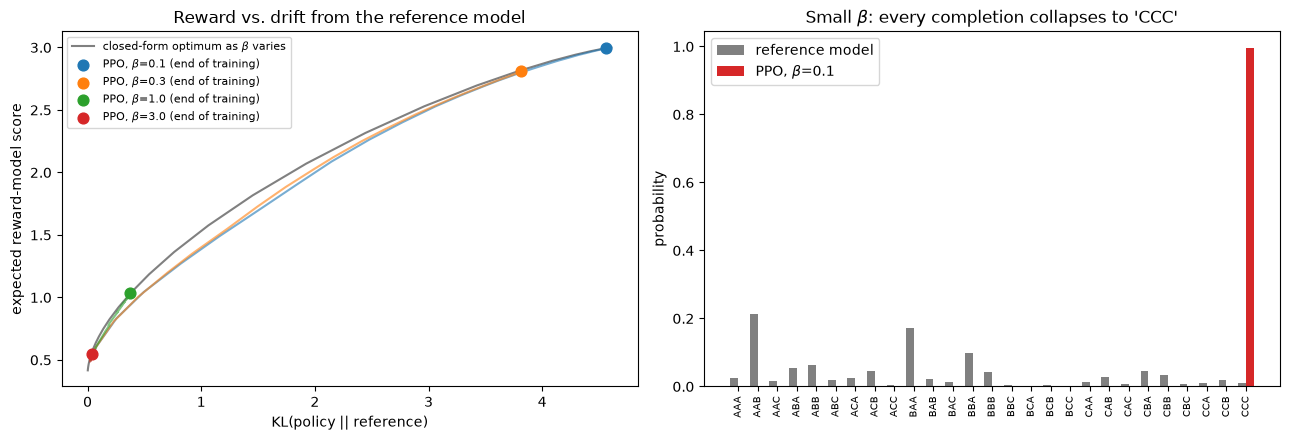

In [14]:
beta_grid = np.logspace(-1.3, 1, 40)
frontier = [(optimal_policy(b) @ RM_SCORE, np.sum(optimal_policy(b) * np.log(optimal_policy(b) / p_ref))) for b in beta_grid]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([f[1] for f in frontier], [f[0] for f in frontier], color="gray", label="closed-form optimum as $\\beta$ varies")
for beta in betas:
    hist = learned[beta][1]
    axes[0].plot(hist[:, 1], hist[:, 0], alpha=0.6)
    axes[0].scatter(hist[-1, 1], hist[-1, 0], s=60, zorder=3, label=f"PPO, $\\beta$={beta} (end of training)")
axes[0].set_xlabel("KL(policy || reference)"); axes[0].set_ylabel("expected reward-model score")
axes[0].set_title("Reward vs. drift from the reference model"); axes[0].legend(fontsize=8)

x = np.arange(27); width = 0.4
axes[1].bar(x - width / 2, p_ref, width, label="reference model", color="gray")
axes[1].bar(x + width / 2, sequence_distribution(learned[0.1][0]), width, label="PPO, $\\beta$=0.1", color="C3")
axes[1].set_xticks(x); axes[1].set_xticklabels([to_text(y) for y in SEQUENCES], rotation=90, fontsize=7)
axes[1].set_ylabel("probability"); axes[1].set_title("Small $\\beta$: every completion collapses to 'CCC'"); axes[1].legend()
plt.tight_layout(); plt.show()

What just happened, and why it is the whole story of RLHF in miniature:

- **PPO found the theoretical optimum.** For every $\beta$, the distribution
  PPO learned matches $\pi_{\text{ref}}(y)\,e^{r(y)/\beta}/Z$. The KL-regularized
  objective, the per-token KL penalty, PPO-clip and the leave-one-out
  advantage all fit together exactly as derived.
- **$\beta$ traces out a trade-off curve** (left). More reward costs more drift
  from the reference model. Each PPO run lands on the curve.
- **Small $\beta$ = reward hacking** (right). With $\beta = 0.1$ the policy
  generates "CCC" essentially always — the reward model's favorite, and a
  completion the reference model almost never produced. In a real LLM this is
  the policy learning to emit whatever the reward model overrates, while
  losing the diversity and fluency of the SFT model. Note that the reward
  model's score went *up*. The reward model can't tell you it's being
  hacked. Only the KL, or human evaluation, can.
- **Large $\beta$ = barely moves.** Safe, but it learns little.

Choosing $\beta$ (often adaptively, targeting a KL budget) is one of the most
consequential knobs in RLHF.

## 9. The LLM mapping

| PPO component (this notebook) | In PPO-based RLHF (notebook 7) |
|---|---|
| actor $\pi_\theta$ (MLP → 2 logits) | the LLM being trained (transformer → vocabulary logits) |
| action $a_t$ | one generated token |
| critic $V_\phi(s)$ | a **value head** on the LLM (or a separate model) predicting return from each prefix |
| GAE over time steps | GAE over **token positions** within each completion |
| reward $r_t$ | 0 at every token except the last: reward-model score at EOS, **minus per-token KL** $\beta\log\frac{\pi_\theta}{\pi_{\text{ref}}}$ |
| $\pi_{\text{old}}$ (log-probs stored at rollout) | the same — log-probs saved during generation |
| $\pi_{\text{ref}}$ | a frozen copy of the SFT model |
| clip $\epsilon$, epochs, minibatches | the same knobs, typically $\epsilon = 0.2$ and 1–4 epochs per batch |
| approx_kl, clip_fraction | the same diagnostics in `trl`'s logs |

That's **four** models in memory at once (policy, value, reference, reward)
— the main practical cost of PPO-based RLHF, and the reason for the
simplifications in the rest of the course:

- **RLOO / GRPO** (notebooks 8–9) delete the value model and use group
  baselines, as in Section 8 above.
- **DPO** (notebook 10) deletes the reward model *and* the RL loop, by solving
  the closed-form $\pi^{*}$ equation for $r$.
- **RLCD** (notebook 11) keeps this exact PPO + KL loop but changes **where
  the preference data comes from**: instead of humans labeling which of two
  responses is better, it generates each pair from a *positive* and a
  *negative* version of the prompt (e.g. "be harmless" vs. "be harmful"), so
  the label is known by construction. A reward model trained on those pairs
  then plays the role of `RM_SCORE` here.

The production versions — a CleanRL-style PPO on gymnasium's CartPole, and
`trl`'s PPO trainer for LLMs, with each argument mapped to the quantities in
this notebook — are in **notebook 10**.

## 10. Recap & exercises

**What we derived and built, from first principles:**

- **Importance sampling**: unbiased, but with variance that explodes as the
  distributions separate. Per-sequence weights are hopeless for long
  sequences, so we use per-step ratios.
- The **surrogate objective**: its gradient equals the policy gradient at
  $\theta_{\text{old}}$. The **performance difference lemma** shows exactly what it
  approximates (it swaps the state distribution), and an exact GridWorld
  experiment showed it overpromising as KL grows.
- **KL divergence**: forward vs. reverse (mode-covering vs. mode-seeking), and
  the **k1/k2/k3 estimators**, with k3 unbiased, non-negative and
  low-variance.
- **TRPO**: natural gradient via Fisher matrix and conjugate gradient, plus a
  line search. Its step is fixed in KL rather than in parameter space, which
  makes it robust where vanilla PG either crawls or collapses.
- **PPO-clip**: derived case by case, gradient derived by hand and
  finite-difference checked, and a full implementation that beats A2C on
  sample efficiency, with an ablation showing clipping is what makes data
  reuse stable.
- **KL-regularized PPO**, the RLHF objective, landing on the closed-form
  optimum $\pi_{\text{ref}}e^{r/\beta}/Z$, with reward hacking demonstrated at small $\beta$.

**Next — Notebook 7: RLHF for LLMs.** Where does $r(y)$ come from when "good"
means "a human would prefer it"? We'll build a **reward model** from pairwise
preferences (the Bradley–Terry model), then plug it into exactly the PPO + KL
loop from Section 8.

### Exercises

1. **Adaptive β.** Instead of a fixed $\beta$, target a KL budget: after each
   iteration, if $\mathrm{KL}(\pi\|\pi_{\text{ref}})$ exceeds the target by 50%,
   double $\beta$; if it's below half the target, halve $\beta$. (This is the
   adaptive KL controller from the original RLHF paper.) Does the policy settle
   at the target KL?
2. **k3 as the penalty.** In `rlhf_ppo`, replace the summed k1 penalty
   $\log(\pi_{\text{old}}/\pi_{\text{ref}})$ with the per-token k3 estimator, as GRPO does. Does
   the policy still converge to $\pi^{*}$? (Careful: k3 estimates
   $\mathrm{KL}(\pi\|\pi_{\text{ref}})$ with $r = \pi_{\text{ref}}/\pi$ — get the direction right.)
3. **Epochs vs. stability.** Re-run PPO on CartPole with 3, 10 and 30 epochs,
   with and without clipping. At what point does clipping stop being able to
   hold the trust region? Watch approx_kl.
4. **PPO-KL instead of PPO-clip.** Replace clipping with an explicit penalty:
   maximize $\mathbb E[\rho_t\hat A_t] - c\,\mathrm{KL}(\pi_{\text{old}}\|\pi_\theta)$, adapting $c$ as in
   exercise 1 (the "PPO-penalty" variant from the PPO paper). Compare
   learning curves and KL traces with PPO-clip.
5. **A second quirk.** Change `RM_SCORE` so the reward model loves "C" but the
   *true* quality you care about is "sequences that start with A." Plot true
   quality against $\beta$. You've just built a miniature of the
   reward-model overoptimization curves reported for real RLHF.